In [1]:
!pip install pandas numpy matplotlib seaborn scipy openpyxl -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [3]:
BASE = Path.cwd()

if BASE.name == "notebooks":
    BASE = BASE.parent

RAW = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
CHARTS = BASE / "reports" / "charts"

PROCESSED.mkdir(exist_ok=True)
CHARTS.mkdir(exist_ok=True)

print(BASE)

C:\Users\chotu\Downloads\Bluestock_Mf_Capstone


In [4]:
nav = pd.read_csv(
    RAW / "02_nav_history.csv"
)

performance = pd.read_csv(
    RAW / "07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    RAW / "10_benchmark_indices.csv"
)


nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav = nav.drop_duplicates()

nav["nav"] = nav.groupby(
    "amfi_code"
)["nav"].ffill()

nav = nav[nav["nav"] > 0]

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [7]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


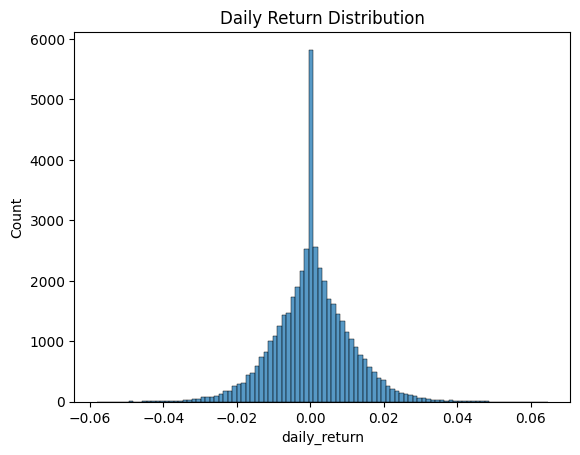

In [8]:
sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [9]:
def CAGR(start,end,years):
    return (
        (end/start)**(1/years)-1
    )

In [10]:
cagr_list=[]

for fund,df in nav.groupby("amfi_code"):

    start=df.iloc[0]["nav"]
    end=df.iloc[-1]["nav"]

    cagr_list.append(
        [
            fund,
            CAGR(start,end,1),
            CAGR(start,end,3),
            CAGR(start,end,5)
        ]
    )


cagr = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
)

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,0.121336,0.038912,0.023168
1,100025,0.211552,0.066058,0.039127
2,100033,2.185142,0.471328,0.260741
3,101206,1.534562,0.363435,0.204427
4,101207,0.399496,0.118555,0.069533


In [11]:
RF = 0.065

sharpe=[]

for fund,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    value = (
        (r.mean()-RF/252)
        /
        r.std()
    ) * np.sqrt(252)

    sharpe.append(
        [fund,value]
    )


sharpe = pd.DataFrame(
    sharpe,
    columns=[
        "amfi_code",
        "Sharpe"
    ]
)

sharpe.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [12]:
sortino=[]

for fund,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside = r[r<0].std()

    value = (
        (r.mean()-RF/252)
        /
        downside
    ) * np.sqrt(252)

    sortino.append(
        [fund,value]
    )


sortino=pd.DataFrame(
    sortino,
    columns=[
        "amfi_code",
        "Sortino"
    ]
)

In [15]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [19]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)


benchmark_100 = benchmark[
    benchmark["index_name"]
    .str.contains("Nifty 100", case=False)
].copy()


benchmark_100 = benchmark_100.sort_values(
    "date"
)


benchmark_100["benchmark_return"] = (
    benchmark_100["close_value"]
    .pct_change()
)


benchmark_100.head()

,date,index_name,close_value,return,benchmark_return


In [20]:
alpha_beta=[]


for fund,df in nav.groupby("amfi_code"):

    temp = df.merge(
        benchmark_100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    temp=temp.dropna()


    result = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )


    alpha_beta.append(
        [
            fund,
            result.intercept*252,
            result.slope
        ]
    )


alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,NaN,NaN
1,100025,NaN,NaN
2,100033,NaN,NaN
3,101206,NaN,NaN
4,101207,NaN,NaN


In [21]:
alpha_beta.to_csv(
    PROCESSED/"alpha_beta.csv",
    index=False
)

In [22]:
drawdown=[]


for fund,df in nav.groupby("amfi_code"):

    running_max = (
        df["nav"]
        .cummax()
    )

    dd = (
        df["nav"]/running_max - 1
    )


    drawdown.append(
        [
            fund,
            dd.min()
        ]
    )


drawdown = pd.DataFrame(
    drawdown,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

drawdown.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [27]:
score = (
    cagr
    .merge(sharpe,on="amfi_code")
    .merge(sortino,on="amfi_code")
    .merge(alpha_beta,on="amfi_code")
    .merge(drawdown,on="amfi_code")
)


score["Fund_Score"] = (

    score["CAGR_3Y"].rank(pct=True)*30

    +

    score["Sharpe"].rank(pct=True)*25

    +

    score["Alpha"].rank(pct=True)*20

    +

    score["Max_Drawdown"]
    .rank(pct=True)*10

)


score["Fund_Score"] *= 100


score.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Sortino,Alpha,Beta,Max_Drawdown,Fund_Score
0,100016,0.121336,0.038912,0.023168,-0.201517,-0.351047,NaN,NaN,-0.247344,NaN
1,100025,0.211552,0.066058,0.039127,-0.567095,-0.941821,NaN,NaN,-0.043083,NaN
2,100033,2.185142,0.471328,0.260741,1.093699,1.829134,NaN,NaN,-0.162172,NaN
3,101206,1.534562,0.363435,0.204427,1.027213,1.799563,NaN,NaN,-0.112916,NaN
4,101207,0.399496,0.118555,0.069533,0.162661,0.276644,NaN,NaN,-0.354469,NaN


In [28]:
score.to_csv(
    PROCESSED/"fund_scorecard.csv",
    index=False
)

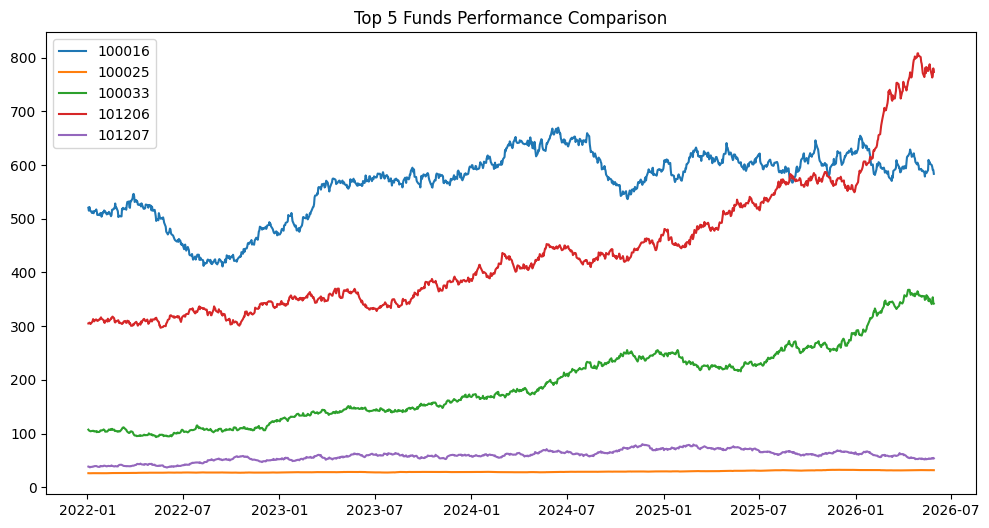

In [29]:
top5 = (
    score.sort_values(
        "Fund_Score",
        ascending=False
    )
    .head(5)
    ["amfi_code"]
)


plt.figure(figsize=(12,6))


for fund in top5:

    temp = nav[
        nav["amfi_code"]==fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=fund
    )


plt.legend()

plt.title(
    "Top 5 Funds Performance Comparison"
)


plt.savefig(
    CHARTS/"benchmark_comparison.png",
    bbox_inches="tight"
)


plt.show()

In [30]:
print(list(PROCESSED.glob("*")))
print(list(CHARTS.glob("*.png")))

[WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/data/processed/.gitkeep'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/data/processed/alpha_beta.csv'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/data/processed/fund_scorecard.csv'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/data/processed/nav_history_cleaned.csv'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/data/processed/performance_cleaned.csv'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/data/processed/transactions_cleaned.csv')]
[WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/reports/charts/age_distribution.png'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/reports/charts/aum_growth.png'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/reports/charts/benchmark_comparison.png'), WindowsPath('C:/Users/chotu/Downloads/Bluestock_Mf_Capstone/reports/charts/category_heatmap.png'), WindowsPath('C:/User